In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from processing import *
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

#Set font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [ ]:
#satellite data 1 + Lab data 2
data1_file_path = 'DataSet/ZY_3.xlsx'
data2_file_path = 'DataSet/ASD_3.xlsx'

data1 = pd.read_excel(data1_file_path) #satellite data
data2 = pd.read_excel(data2_file_path) #Lab data
label = pd.read_excel(data1_file_path)

features = data1.iloc[:,7:].values
features = features.astype('float64')

ads_features = data2.iloc[:,5:].values
features = features.astype('float64')

select_label = 4 #Choose which label's content to use

labels = label.iloc[:,select_label].values
labels = labels.astype('float64')

wavelengths = np.linspace(400, 2500, 136)

wavelengths = data1.columns[7:]

print('The dimension of the satellite data features is:{}'.format(features.shape))
print('The dimension of the lab data features is:{}'.format(ads_features.shape))
print('The dimensions of the label are:{}'.format(labels.shape))
print(wavelengths.shape)
# print(labels.dtype)
# print(features[:5])
# print(labels[:5])

In [ ]:
from processing import *
# DS
features = direct_standardization_improved(ads_features, features)
print("DS calibration completed. The shape of the satellite spectrum after calibration:", features.shape)
    
# PDS
# features = piecewise_direct_standardization(ads_features, features, n_segments=10)
# print("PDS:", features.shape)

features = PiecewiseDirectStandardization(
    master_spectra=ads_features,
    slave_spectra=features,
    window_half_size=5,
    n_components=3,
    verbose=True
)
features = features[:,5:132]
print("PDS calibration completed. The shape of the satellite spectrum after calibration:", features.shape)  
print(labels.shape)

In [ ]:
# x_train,x_test,y_train,y_test = train_test_split(labels,test_size=0.2,random_state=666) #Random split

# x_train,x_test,y_train,y_test = ks(features,labels,test_size=0.3) #KS
x_train, x_test, y_train, y_test = fast_ks(features, labels, test_size=0.3)

# x_train, x_test, y_train, y_test, z_train, z_test = train_test_split(features, labels, ads_features, test_size=0.2, random_state=42)

# from kennard_stone import train_test_split   #KS
# x_train, x_test, y_train, y_test = train_test_split(selected_spectra, labels, test_size=0.2)

# check_negative_values(x_train)
# check_negative_values(x_test)
print(y_train.shape)
print(x_test.shape)
# Remove the dimensions of size 1 in y_train
y_train = np.squeeze(y_train)
print(y_train.shape)

(187, 1)
(79, 127)
(187,)


In [ ]:
# Get rid of extreme labels
low, high = np.percentile(y_train, [2.5, 97.5])
mask = (y_train >= low) & (y_train <= high)
x_train = x_train[mask]
y_train = y_train[mask]

In [ ]:
from sklearn.utils import resample
import numpy as np

print(y_train.shape)

# sqrt
y_train_sqrt = np.sqrt(y_train)

# Divided into low, medium, and high areas
low_thresh = np.percentile(y_train_sqrt, 33)
high_thresh = np.percentile(y_train_sqrt, 66)

# Group index
low_idx = y_train_sqrt < low_thresh
mid_idx = (y_train_sqrt >= low_thresh) & (y_train_sqrt < high_thresh)
high_idx = y_train_sqrt >= high_thresh

# Downsample based on the smallest sample category
min_count = min(np.sum(low_idx), np.sum(mid_idx), np.sum(high_idx))

# Downsampling parts
x_low, y_low = resample(x_train[low_idx], y_train[low_idx], n_samples=min_count, random_state=42)
x_mid, y_mid = resample(x_train[mid_idx], y_train[mid_idx], n_samples=min_count, random_state=42)
x_high, y_high = resample(x_train[high_idx], y_train[high_idx], n_samples=min_count, random_state=42)

# Merge
x_train = np.concatenate([x_low, x_mid, x_high], axis=0)
y_train = np.concatenate([y_low, y_mid, y_high], axis=0)

print(x_train.shape)
print(y_train.shape)

(177,)
(174, 127)
(174,)


In [ ]:
from scipy.signal import savgol_filter,butter, sosfilt,find_peaks
from processing import *

#train set
# SNV
x_train_prepro = snv_correction(x_train)
#SG
x_train_prepro = savgol_filter(x_train_prepro ,window_length=7 ,polyorder=2) 
# x_train_prepro = savgol_filter(x_train ,window_length=7 ,polyorder=2) 
# MSC
# x_train_prepro, mean_spectrum = do_msc(x_train_prepro)
#FD
x_train_prepro = np.diff(x_train_prepro,axis=1) 
# x_train_prepro = np.diff(x_train,axis=1) 

#x_train_prepro = DWT(x_train_prepro)
# x_train_prepro = deconvolve_spectra(x_train_prepro)
# x_train_prepro = np.log(1 / (x_train + 1e-10))  


#testing set
print(x_test.shape)
# SNV
x_test_prepro = snv_correction(x_test)
#SG
x_test_prepro = savgol_filter(x_test_prepro ,window_length=7 ,polyorder=2)
# x_test_prepro = savgol_filter(x_test ,window_length=7 ,polyorder=2)
# MSC
# x_test_prepro, mean_spectrum = do_msc(x_test_prepro)
#FD
x_test_prepro = np.diff(x_test_prepro,axis=1)
# x_test_prepro = np.diff(x_test,axis=1)

#x_test_prepro = DWT(x_test_prepro)
# x_test_prepro = deconvolve_spectra(x_test_prepro)
# x_test_prepro = np.log(1 / (x_test + 1e-10))  

# check_negative_values(x_train_prepro)
# check_negative_values(x_test_prepro)
print(x_train_prepro.shape)
print(x_test_prepro.shape)


(79, 127)
(174, 126)
(79, 126)


In [ ]:
# CARS
from processing import *
x_train_index = cars(x_train_prepro, y_train, 10 , n_folds=5, random_state = 45)  
print('The selected index is:{}'.format(x_train_index)) 

x_train_end = x_train_prepro[:,x_train_index] 
x_test_end = x_test_prepro[:,x_train_index]

In [ ]:
import torch
import torch.nn as nn

# Loss function
class WeightedHuberLoss(nn.Module):
    def __init__(self, delta=1.0, low_th=33.3, high_th=66.6,
                 low_weight=2.0, middle_weight=1.0, high_weight=2.0):
        super(WeightedHuberLoss, self).__init__()
        self.delta = delta
        self.low_th = low_th
        self.high_th = high_th
        self.low_weight = low_weight
        self.middle_weight = middle_weight
        self.high_weight = high_weight

    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        abs_error = torch.abs(error)

        # Huber loss
        loss = torch.where(abs_error < self.delta,
                           0.5 * error ** 2,
                           self.delta * (abs_error - 0.5 * self.delta))

        # Assign weights in segments based on y_true
        weights = torch.ones_like(y_true)

        weights[y_true < self.low_th] = self.low_weight
        weights[(y_true >= self.low_th) & (y_true <= self.high_th)] = self.middle_weight
        weights[y_true > self.high_th] = self.high_weight

        # weighted_loss = weights * loss
        weighted_loss = weights * (loss ** 2)  # Strengthen high-value segment loss

        return weighted_loss.mean()
    
def set_seed(seed=42):
    import os
    import random
    import numpy as np
    import torch

    # Python's randomness
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # The randomness of Numpy
    np.random.seed(seed)

    # The randomness of PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Multi-GPU

    # Ensure cudnn reproducibility (slightly sacrificing speed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import copy
from models import *
from transformers import get_linear_schedule_with_warmup,get_cosine_schedule_with_warmup

set_seed(47)

epsilon = 1e-6

# 1.1 Input feature normalization
x_scaler = MinMaxScaler()
x_train = x_scaler.fit_transform(x_train_end)
x_test = x_scaler.transform(x_test_end)

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()  # Train label normalization
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()        # Test label normalization

# ========== 2.  Tensor ==========
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

# ========== 3. Data Loading ==========
# batch_size =256
batch_size =128
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor), batch_size=len(x_test_tensor), shuffle=False)

# ========== 4. Model, optimizer, loss ==========
wavelengths=data1.columns[12:139]
wavelengths=wavelengths[x_train_index]
# print(wavelengths)
segment_ids = generate_segment_ids(wavelengths, num_segments=3)

# model = SpectralTransformer2(
#     # num_bands=10, hidden_dim=256, num_heads=8, num_layers=6, dropout=0.02, wavelengths=wavelengths
#     hidden_dim=128, num_heads=8, num_layers=6, dropout=0.2
#     # hidden_dim=128, num_heads=8, num_layers=4, dropout=0.3
# )

# model = SpectralTransformerV2_Lite_Improved_V2(
#     # num_bands=10, hidden_dim=64, num_heads=4, num_layers=3, dropout=0.3, wavelengths=wavelengths
#     num_bands=10, hidden_dim=128, num_heads=4, num_layers=3, dropout=0.3, wavelengths=wavelengths
# )

model = SpectralTransformerV2_Lite_Improved_V4(
    # num_bands=10, hidden_dim=128, num_heads=8, num_layers=6, dropout=0.3, wavelengths=wavelengths,segment_ids=segment_ids
    # num_bands=10, hidden_dim=128, num_heads=4, num_layers=6, dropout=0.3, wavelengths=wavelengths,segment_ids=segment_ids
    num_bands=10, hidden_dim=128, num_heads=8, num_layers=4, dropout=0.3, wavelengths=wavelengths,segment_ids=segment_ids
)

epochs = 350

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)#weight_decay=1e-5
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=89, gamma=0.82)

# criterion = torch.nn.HuberLoss(delta=1.0)  
criterion = WeightedHuberLoss(delta=1.0, low_th=33.3, high_th=50.6,
                               low_weight=5.0, middle_weight=1.0, high_weight=50.0)


# ========== 5. Train ==========
train_loss_list, train_r2_list, test_r2_list = [], [], []
best_r2 = -np.inf
patience, wait = 150, 0


for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    train_loss_list.append(epoch_loss / len(train_loader))

    # Assessment
    model.eval()
    with torch.no_grad():
        train_pred, y_train_tensor = zip(*[(model(x), y) for x, y in train_loader])
        train_pred = torch.cat(train_pred)
        y_train_tensor = torch.cat(y_train_tensor)
        test_pred = torch.cat([model(bx) for bx, _ in test_loader])

        # Denormalization
        train_pred_real = y_scaler.inverse_transform(train_pred)
        test_pred_real = y_scaler.inverse_transform(test_pred)
        y_train_real = y_scaler.inverse_transform(y_train_tensor)
        y_test_real = y_scaler.inverse_transform(y_test_tensor)

        train_r2 = r2_score(y_train_real, train_pred_real)
        test_r2 = r2_score(y_test_real, test_pred_real)
        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)


# ========== 6. Final Assessment ==========
model.eval()

# ===  Save model weights ===
torch.save(model.state_dict(), 'D:/work/Blueberry2/model_weights.pth')

import joblib
joblib.dump(model, 'D:/work/Blueberry2/som_model.pkl')
joblib.dump(wavelengths, 'D:/work/Blueberry2/wavelengths.pkl')
joblib.dump(segment_ids, 'D:/work/Blueberry2/segment_ids.pkl')

with torch.no_grad():
    train_pred, y_train_tensor = zip(*[(model(x), y) for x, y in train_loader])
    train_pred = torch.cat(train_pred)
    y_train_tensor = torch.cat(y_train_tensor)
    test_pred = torch.cat([model(bx) for bx, _ in test_loader])

train_pred_real = y_scaler.inverse_transform(train_pred)
test_pred_real = y_scaler.inverse_transform(test_pred)
y_train_real = y_scaler.inverse_transform(y_train_tensor)
y_test_real = y_scaler.inverse_transform(y_test_tensor)

# ========== 7. Evaluation metrics ==========
train_r2 = r2_score(y_train_real, train_pred_real)
test_r2 = r2_score(y_test_real, test_pred_real)
train_rmse = mean_squared_error(y_train_real, train_pred_real, squared=False)
test_rmse = mean_squared_error(y_test_real, test_pred_real, squared=False)

def calculate_rpd(y_true, y_pred):
    # print(y_pred[:10])
    return np.std(y_true) / mean_squared_error(y_true, y_pred, squared=False)

def calculate_rpiq(y_true, y_pred):
    q75, q25 = np.percentile(y_true, [75, 25])
    return (q75 - q25) / mean_squared_error(y_true, y_pred, squared=False)

train_rpd = calculate_rpd(y_train_real, train_pred_real)
test_rpd = calculate_rpd(y_test_real, test_pred_real)
train_rpiq = calculate_rpiq(y_train_real, train_pred_real)
test_rpiq = calculate_rpiq(y_test_real, test_pred_real)

# ========== 8. Output result ==========
print(f"Train R2: {train_r2:.4f}, RMSE: {train_rmse:.4f}, RPD: {train_rpd:.4f}, RPIQ: {train_rpiq:.4f}")
print(f"Test  R2: {test_r2:.4f}, RMSE: {test_rmse:.4f}, RPD: {test_rpd:.4f}, RPIQ: {test_rpiq:.4f}")

d:\Anaconda3\envs\Maize\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


[[44.79958183]
 [42.55356622]
 [65.11437489]
 [45.81323028]
 [48.14060831]
 [54.02661202]
 [58.57418139]
 [50.04115206]
 [50.52025565]
 [58.57418139]]
[[41.34560241]
 [71.06532142]
 [23.71953971]
 [42.38261721]
 [68.79322319]
 [39.66711439]
 [39.61743577]
 [33.66625869]
 [56.16015551]
 [45.4153097 ]]
Train R2: 0.8993, RMSE: 4.1509, RPD: 3.1514, RPIQ: 3.9871
Test  R2: 0.5263, RMSE: 12.2293, RPD: 1.4529, RPIQ: 1.8644


In [ ]:
#Inversion result

import torch
import numpy as np
import pandas as pd
import joblib
from models import SpectralTransformerV2_Lite_Improved_V4, generate_segment_ids
from processing import *

# ==================== Read spectral data ====================
file_path = 'D:/work/Blueberry2/DataSet/predict.xlsx'
df = pd.read_excel(file_path)

X_new = df.iloc[:, 2:].values  # shape: (16746, 136)
print("new shape:", X_new.shape)

# # DS
# X_new = direct_standardization_improved(ads_features, X_new)
# print("DS :", X_new.shape)
    
# # PDS
# # features = piecewise_direct_standardization(ads_features, features, n_segments=10)
# # print("PDS :", features.shape)

# features = PiecewiseDirectStandardization(
#     master_spectra=ads_features,
#     slave_spectra=X_new,
#     window_half_size=5,
#     n_components=3,
#     verbose=True
# )
X_new = X_new[:,5:132]
print("Calibration completed. The shape of the calibrated satellite spectrum:", X_new.shape)  

X_new = snv_correction(X_new)
X_new = savgol_filter(X_new ,window_length=7 ,polyorder=2) 
X_new = np.diff(X_new,axis=1) 

X_new = X_new[:,x_train_index]

X_new_scaled = x_scaler.transform(X_new)
X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)


# ==================== Load model weights ====================
model_path = 'D:/work/Blueberry2/model_weights.pth'  
state_dict = torch.load(model_path, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

# ==================== Batch Prediction ====================
batch_size = 256
predictions = []

with torch.no_grad():
    for i in range(0, len(X_new_tensor), batch_size):
        batch = X_new_tensor[i:i + batch_size]  # [B, 136]
        pred = model(batch)                  
        predictions.append(pred)

pred_tensor = torch.cat(predictions, dim=0)     # [16746, 1]
pred_numpy = pred_tensor.numpy().reshape(-1, 1)

# ==================== Denormalization ====================
soc_predicted_real = y_scaler.inverse_transform(pred_numpy).flatten()

# ==================== Save the results ====================
results = pd.DataFrame({
    'Longitude': df.iloc[:, 0],
    'Latitude': df.iloc[:, 1],
    'Predicted_SOC': soc_predicted_real
})

output_path = 'D:/work/Blueberry2/predicted_SOC_results1.csv'
results.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Prediction complete! The results have been saved as: {output_path}")
print(f"Total prediction {len(results)} ")

100%|██████████| 174/174 [00:29<00:00,  5.85it/s]


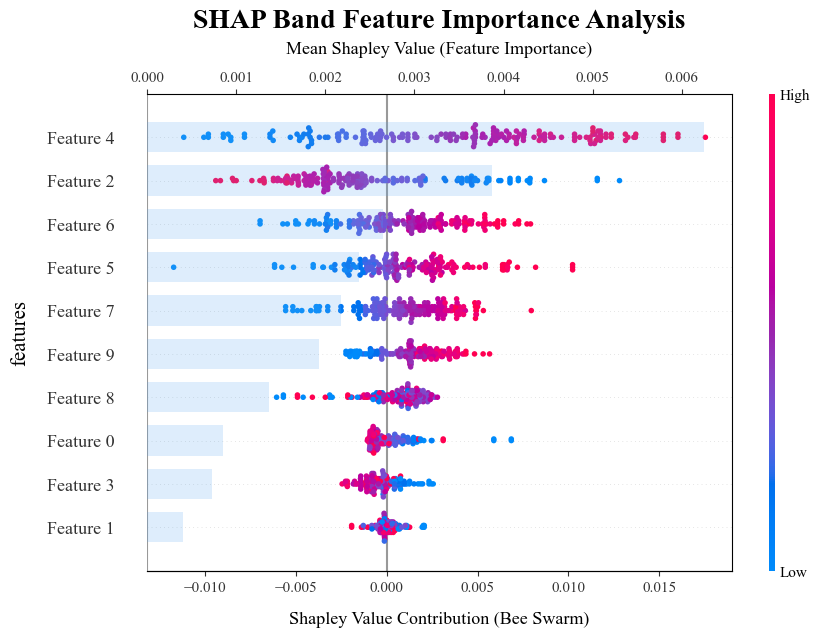

In [ ]:
import shap
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader


X_explain = x_train_end  # shape: [n_samples, n_bands], e.g., [20, 136]
print(X_explain.shape)

# Background data: used for SHAP calculation reference values, usually also taken from x_train_end
X_background = x_train_end[:10]  # shape: [n_background, n_bands], e.g., [10, 136]

# =========================
# 2. Define model prediction function (critical!)
# Input: numpy array [n_samples, n_bands], Output: numpy array [n_samples,]
# =========================

def model_predict_fn(X):
    """
    X: numpy array, shape [n_samples, n_bands] (e.g., [20, 136])
    Returns: numpy array, shape [n_samples,] (regression values)
    """
    X_tensor = torch.tensor(X, dtype=torch.float32)  # Convert to PyTorch Tensor
    with torch.no_grad():
        model.eval()  # Your model is a PyTorch model with .eval() method
        preds = model(X_tensor)  # Model returns a Tensor, shape: [n_samples, 1]
    return preds.numpy().flatten()  # Convert to numpy array, shape: [n_samples,]

# =========================
# 3. Create SHAP KernelExplainer (or DeepExplainer, recommend trying KernelExplainer first)
# =========================

# Create explainer
explainer = shap.KernelExplainer(
    model=model_predict_fn,  # Your prediction function
    data=X_background        # Background data, used to compute baseline predictions
)

# =========================
# 4. Compute SHAP values
# =========================

shap_values_numpy = explainer.shap_values(X_explain)  # shape: [n_samples, n_bands]

# If your model is regression, shap_values is a 2D array: [n_samples, n_features]
# If classification (multi-class), shap_values is a list, each element corresponds to one class

# =========================
# 5. Visualize SHAP results
# =========================
import sys
import os
# Redirect standard output to os.devnull
sys.stdout = open(os.devnull, 'w')
feature_names = list(wavelengths.astype(str))

# Create main figure for bee swarm plot
fig, ax1 = plt.subplots(figsize=(10, 8))
# Draw bee swarm plot on the main axes, keep color bar
shap.summary_plot(shap_values_numpy,
                   x_train_end, 
                   # feature_names=[f"Band_{i}" for i in range(X_explain.shape[1])], 
                   feature_names = feature_names,  # List comprehension
                   plot_type="dot", 
                   show=False, 
                   color_bar=True)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # Adjust chart position, leave space for color bar on the right

# 3. Get all axes from current figure (including color bar axes)
all_axes = plt.gcf().axes  # Get all axes in the current figure

# 4. Usually the last axis is the color bar (small plot on the right); set its label
if len(all_axes) >= 2:
    colorbar_ax = all_axes[-1]  # Assume the last axis is the color bar
    colorbar_ax.set_ylabel(" ", rotation=270, labelpad=8, fontsize=13)
    # Optional: set font size, rotation angle, label distance from axis, etc.
else:
    print("Color bar axis not detected. Please confirm color_bar=True is effective or SHAP rendering is normal.")

# Get the shared y-axis
ax1 = plt.gca()
# Create another axes sharing the same y-axis for plotting feature importance on top x-axis
ax2 = ax1.twiny()
shap.summary_plot(shap_values_numpy,
                   x_train_end, 
                   color="#5ba8f0",  # Set color here
                   plot_type="bar", 
                   show=False)
plt.title('SHAP Band Feature Importance Analysis', fontsize=20, fontweight='bold', pad=10)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # Adjust chart position, align with bee swarm plot
# Add a horizontal line on the top x-axis
ax2.axhline(y=13, color='black', linestyle='-', linewidth=1)  # Note: y value should correspond to the top

ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
# Adjust transparency
bars = ax2.patches  # Get all bar objects
for bar in bars:
    bar.set_alpha(0.2)  # Set transparency
# Set labels for both x-axes
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=13, labelpad=12)
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=13, labelpad=12)
# Move the top x-axis to avoid overlapping with bottom x-axis
ax2.xaxis.set_label_position('top')  # Move label to top
ax2.xaxis.tick_top()  # Move ticks to top as well
# Set y-axis label
ax1.set_ylabel('Features', fontsize=15, labelpad=12)

plt.tight_layout()
# plt.savefig("SHAP_1.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.show()

<Figure size 9600x7200 with 0 Axes>

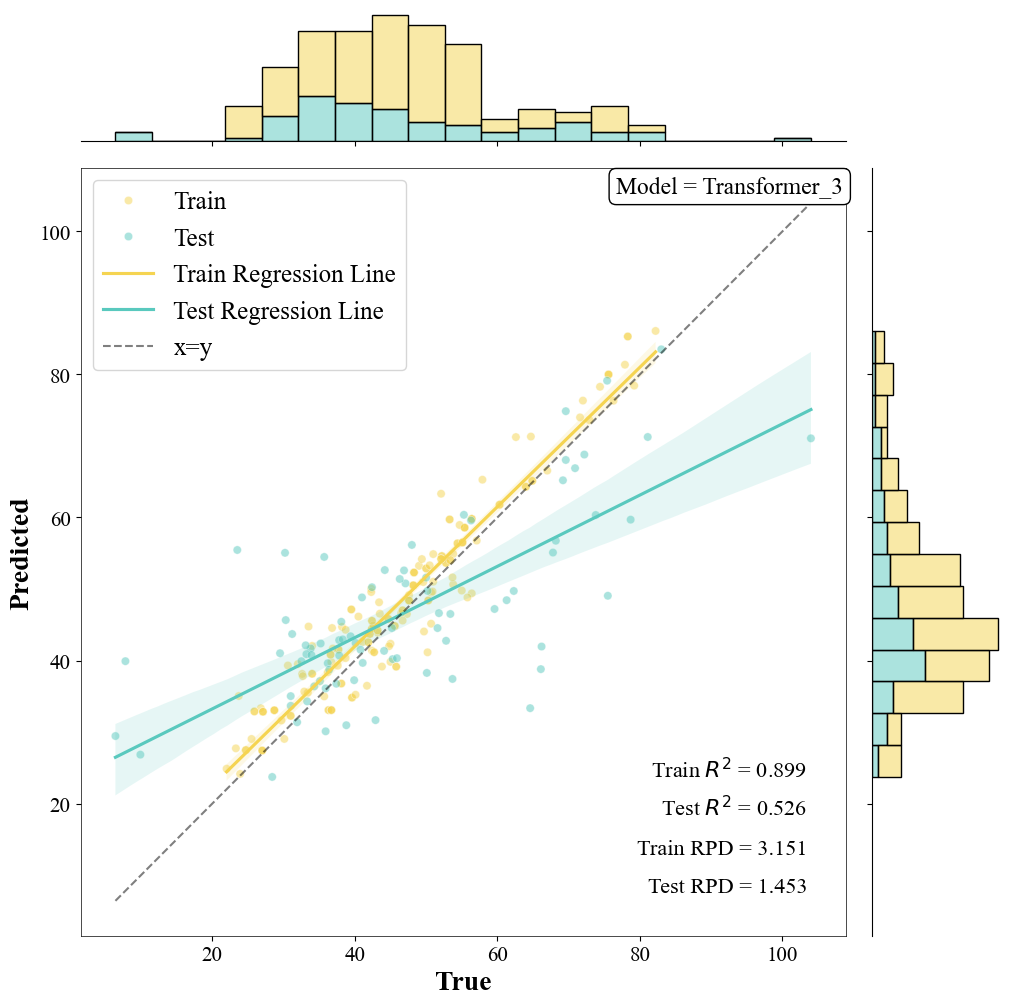

In [ ]:
# Model visualization
# print("y_train_real shape:", y_train_real.shape)
# print("train_pred_real shape:", train_pred_real.shape)
# print("y_test_real shape:", y_test_real.shape)
# print("test_pred_real shape:", test_pred_real.shape)

y_train_real = y_train_real.flatten()   # .ravel()
train_pred_real = train_pred_real.flatten()
y_test_real = y_test_real.flatten()
test_pred_real = test_pred_real.flatten()



import seaborn as sns
from sklearn import metrics

# Create a DataFrame containing true and predicted values for training and test sets
data_train = pd.DataFrame({
    'True': y_train_real,
    'Predicted': train_pred_real,
    'Data Set': 'Train'
})

data_test = pd.DataFrame({
    'True': y_test_real,
    'Predicted': test_pred_real,
    'Data Set': 'Test'
})

data = pd.concat([data_train, data_test])

# Custom color palette
palette = {'Train': "#f5d451", 'Test': "#59c9be"}

# Create JointGrid object
plt.figure(figsize=(8, 6), dpi=1200)
g = sns.JointGrid(data=data, x="True", y="Predicted", hue="Data Set", height=10, palette=palette)

# Set axis label font size
g.set_axis_labels('True Value', 'Predicted Value', fontsize=20, fontweight='bold')

# Set axis tick font size
g.ax_joint.tick_params(axis='both', which='major', labelsize=15)


# Draw center scatter plot
g.plot_joint(sns.scatterplot, alpha=0.5)
# Add regression line for training set
sns.regplot(data=data_train, x="True", y="Predicted", scatter=False, ax=g.ax_joint, color='#f5d451', label='Train Regression Line')
# Add regression line for test set
sns.regplot(data=data_test, x="True", y="Predicted", scatter=False, ax=g.ax_joint, color='#59c9be', label='Test Regression Line')
# Add marginal histograms
g.plot_marginals(sns.histplot, kde=False, element='bars', multiple='stack', alpha=0.5)


# Add full axis borders
ax = g.ax_joint
# Show all four borders
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Set border color and width
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.5)


# Add goodness-of-fit text in lower right corner
ax = g.ax_joint
ax.text(0.95, 0.2, f'Train $R^2$ = {train_r2:.3f}', transform=ax.transAxes, fontsize=16,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="white", facecolor="white"))
ax.text(0.95, 0.15, f'Test $R^2$ = {test_r2:.3f}', transform=ax.transAxes, fontsize=16,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="white", facecolor="white"))
ax.text(0.95, 0.1, f'Train RPD = {train_rpd:.3f}', transform=ax.transAxes, fontsize=16,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="white", facecolor="white"))
ax.text(0.95, 0.05, f'Test RPD = {test_rpd:.3f}', transform=ax.transAxes, fontsize=16,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="white", facecolor="white"))

# Add model name text in upper left corner (0.73, 0.7)
ax.text(0.7, 0.99, 'Model = Transformer_3', transform=ax.transAxes, fontsize=17,
        verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

# Add center line (1:1 line)
ax.plot([data['True'].min(), data['True'].max()], [data['True'].min(), data['True'].max()], c="black", alpha=0.5, linestyle='--', label='x=y')
ax.legend(fontsize=18)
plt.savefig("TrueFalse.pdf", format='pdf', bbox_inches='tight')
plt.show()
